In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [16]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
print("shape: ", orders.shape)
print("info", orders.info())
orders.describe()
orders.describe(include='object')

orders.isnull().sum()
orders.columns

shape:  (99441, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
info None


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [18]:
# prefare to questions
orders['order_status'].value_counts() # return list of statuses and counts

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col]) # turn dates into a datetime

orders['delivery_time_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days
orders['delivery_time_days'].describe() # create delivery_time feature_days

,delivery_time_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


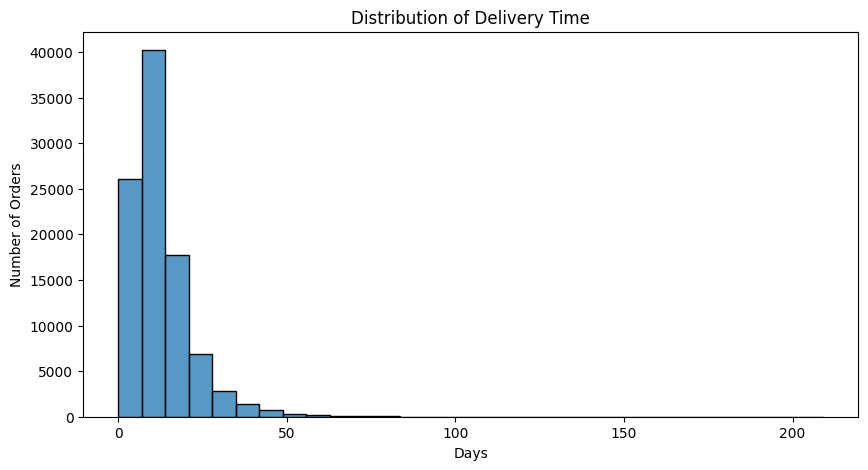

In [19]:
# visualization

plt.figure(figsize=(10,5))

sns.histplot(orders['delivery_time_days'], bins=30)

plt.title('Distribution of Delivery Time')
plt.xlabel('Days')
plt.ylabel('Number of Orders')

plt.show()

Key Business Insights
1. The platform experienced strong order growth throughout 2017.
2. Order volume fluctuated moderately during 2018.
3. A sharp decline appears after August 2018, likely due to incomplete data coverage.
4. Cancellation rate is relatively low (~0.63%), indicating stable operational performance.
5.Revenue trends generally follow order volume trends, suggesting growth is primarily driven by increased order count.

In [20]:
orders['purchase_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

orders['purchase_month'].head()

,purchase_month
0,2017-10
1,2018-07
2,2018-08
3,2017-11
4,2018-02


In [21]:
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')

sales = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

In [22]:
orders.columns.tolist()

sales.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_time_days',
 'purchase_month',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

Key Findings So Far
Strong growth during 2017 and early 2018
Order volume increased steadily over time.
Revenue appears to follow order volume
Growth seems to be driven primarily by more orders rather than a dramatic increase in order value.
Low cancellation rate (~0.63%)
Indicates relatively stable operational performance.
Delivery time outliers exist
Some orders experienced unusually long delivery times and should be investigated further.
Sharp decline after August 2018 is likely a data coverage issue
The dataset ends during September 2018, making the final period incomplete.

In [30]:
monthly_revenue = (
    sales
    .groupby('purchase_month')['price']
    .sum()
    .reset_index()
)

monthly_revenue.head()



,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


In [33]:
# AOV

order_revenue = (
    sales
    .groupby('order_id')['price']
    .sum()
)

aov = order_revenue.mean()

print(f'Average Order Value: {aov:.2f}')

Average Order Value: 137.75


# The average order value (AOV) is 137.75, indicating the typical revenue generated per order.

In [36]:
# Note
print(monthly_revenue.tail())
print(sales['purchase_month'].min())
print(sales['purchase_month'].max())

# the strongest months
monthly_revenue.sort_values(
    by='price',
    ascending=False
).head(10)

   purchase_month      price
19        2018-05  996517.68
20        2018-06  865124.31
21        2018-07  895507.22
22        2018-08  854686.33
23        2018-09     145.00
2016-09
2018-09


Revenue Insights

1. Revenue grew substantially throughout the observed period.

The platform experienced significant revenue growth between 2017 and 2018.

2. Average Order Value remained around 137.75 per order.

This metric represents the average revenue generated per completed order.

3. The earliest months contain unusually low revenue values.

These months likely represent partial data coverage and should be interpreted with caution.

In [37]:
monthly_revenue['growth_pct'] = (
    monthly_revenue['price']
    .pct_change() * 100
)

monthly_revenue[['purchase_month', 'price', 'growth_pct']].head(15)

,purchase_month,price,growth_pct
0,2016-09,267.36,NaN
1,2016-10,49507.66,1.841723e+04
2,2016-12,10.90,-9.997798e+01
3,2017-01,120312.87,1.103688e+06
4,2017-02,247303.02,1.055499e+02
5,2017-03,374344.30,5.137069e+01
6,2017-04,359927.23,-3.851286e+00
7,2017-05,506071.14,4.060374e+01
8,2017-06,433038.60,-1.443128e+01
9,2017-07,498031.48,1.500857e+01


Growth rates for the earliest months were excluded from interpretation due to incomplete data coverage, which resulted in artificially inflated percentage changes.

In [38]:
# lets fix this
monthly_revenue_clean = monthly_revenue[
    monthly_revenue['purchase_month'] >= '2017-01'
]

monthly_revenue_clean['growth_pct'] = (
    monthly_revenue_clean['price']
    .pct_change() * 100
)

/tmp/ipykernel_987/1507157141.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_revenue_clean['growth_pct'] = (


In [39]:
# did revenue grow because of quality or quantity?
# lets do AOV Trend Analysis
# does Average Order Value stay stable during time?

order_monthly_revenue = (
    sales[['order_id', 'purchase_month']]
    .drop_duplicates()
    .merge(order_revenue, on='order_id')
)

order_monthly_revenue.head()


,order_id,purchase_month,price
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,19.90


In [42]:
monthly_aov = (
    order_monthly_revenue
    .groupby('purchase_month')['price']
    .mean()
    .reset_index()
)

monthly_aov.head()

monthly_aov['price'].describe()

,price
count,24.000000
mean,132.708731
std,29.144418
min,10.900000
25%,132.420056
50%,139.356531
75%,145.101764
max,160.739156


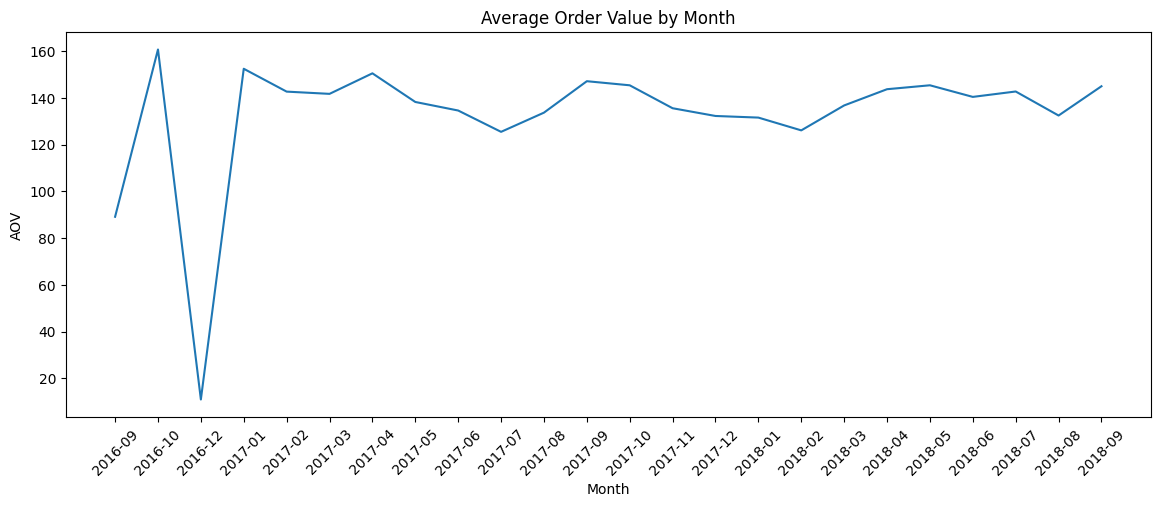

In [41]:
plt.figure(figsize=(14,5))

sns.lineplot(
    data=monthly_aov,
    x='purchase_month',
    y='price'
)

plt.title('Average Order Value by Month')
plt.xlabel('Month')
plt.ylabel('AOV')

plt.xticks(rotation=45)

plt.show()

Average Order Value remained relatively stable throughout most of the observation period, suggesting that revenue growth was primarily driven by increasing order volume rather than higher spending per order.

Average Order Value remained relatively stable throughout the observed period, fluctuating mostly between 126 and 145. This suggests that revenue growth was driven primarily by increasing order volume rather than by higher spending per order.

After the initial period, average order value showed only moderate fluctuations, indicating a relatively consistent purchasing behavior among customers.

_______________


Revenue & Orders Insights

1. Strong business growth

Order volume and revenue increased substantially throughout 2017 and early 2018.

2. Low cancellation rate

Only ~0.63% of orders were canceled, suggesting stable operational performance.

3. Revenue growth was volume-driven

Average Order Value remained relatively stable over time, indicating that revenue growth was mainly driven by an increase in the number of orders.

4. Stable customer spending behavior Customers spent a similar amount per order throughout most of the observed period.

5. Incomplete data at the dataset boundaries

Extremely low values at the beginning and end of the timeline likely reflect partial monthly coverage rather than actual business performance.

In [44]:
monthly_aov.tail(10)

,purchase_month,price
14,2017-12,132.274924
15,2018-01,131.583152
16,2018-02,126.109756
17,2018-03,136.785398
18,2018-04,143.733451
19,2018-05,145.413349
20,2018-06,140.442258
21,2018-07,142.755814
22,2018-08,132.468433
23,2018-09,145.000000


In [45]:
items_per_order = (
    sales
    .groupby('order_id')['order_item_id']
    .count()
)

items_per_order.describe()

,order_item_id
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


Most orders contain a single item, with relatively few multi-item purchases